# Walmart Sales vs Parking Occupancy — Correlation Analysis

Tests whether **inflation-adjusted Walmart revenue** correlates with **average parking lot occupancy** derived from NAIP aerial imagery.

| Data source | File | Granularity |
|---|---|---|
| Walmart revenue | `Data/walmart_annual_revenue.csv` | Annual, 2012–2023 |
| US CPI inflation | `Data/inflation.csv` | Annual, World Bank |
| Parking occupancy | `Data/naip_occupancy_pixel_ratio.csv` | Per store × date, aggregated to annual |

**Occupancy metric:** `occupied_pixels / total_image_pixels` (see `naip_inference_pixel_ratio.ipynb`).

**Deflation method:** cumulative CPI index anchored at 2012, same approach as `data_collection/walmart_sales.ipynb`.

## 1 · Load & Prepare Data

In [122]:
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

DATA = Path("../../Data")

In [123]:
# ── Nominal revenue (millions USD) ─────────────────────────────────────────
df_rev = pd.read_csv(DATA / "walmart_annual_revenue.csv")

# ── US CPI inflation rates (World Bank) ────────────────────────────────────
df_cpi_raw = pd.read_csv(DATA / "inflation.csv", skiprows=4)
years_available = [str(y) for y in range(2012, 2024) if str(y) in df_cpi_raw.columns]

df_cpi = (
    df_cpi_raw[df_cpi_raw["Country Code"] == "USA"][years_available]
    .melt(var_name="year", value_name="inflation")
    .assign(year=lambda x: x["year"].astype(int))
    .reset_index(drop=True)
)

# ── Merge & deflate (cumulative CPI index anchored at first year) ───────────
df = pd.merge(df_rev, df_cpi, on="year").sort_values("year").reset_index(drop=True)
df["cpi_multiplier"]  = 1 + df["inflation"] / 100
df["cpi_cumulative"]  = df["cpi_multiplier"].cumprod()
df["revenue_real"]    = (df["revenue"] / df["cpi_cumulative"]).round(0).astype(int)

print("Walmart annual revenue (deflated to 2012 dollars)\n")
print(df[["year", "revenue", "inflation", "revenue_real"]].to_string(index=False))

Walmart annual revenue (deflated to 2012 dollars)

 year  revenue  inflation  revenue_real
 2012   446509   2.069337        437457
 2013   468651   1.464833        452521
 2014   476294   1.622223        452559
 2015   485651   0.118627        460903
 2016   482130   1.261583        451861
 2017   485873   2.130110        445872
 2018   500343   2.442583        448203
 2019   514405   1.812210        452597
 2020   523964   1.233584        455390
 2021   559151   4.697859        464166
 2022   572754   8.002800        440228
 2023   611289   4.116338        451271


In [124]:
# ── Parking occupancy — annual mean across all stores ──────────────────────
df_occ = pd.read_csv(DATA / "naip_occupancy_pixel_ratio.csv", parse_dates=["date"])
df_occ["year"] = df_occ["date"].dt.year

occ_annual = (
    df_occ.groupby("year")["occupancy"]
    .agg(occ_mean="mean", occ_std="std", n_images="count")
    .reset_index()
)
occ_annual["occ_pct"] = occ_annual["occ_mean"] * 100

print("Annual mean parking occupancy (% of total image pixels)\n")
print(occ_annual[["year", "occ_pct", "occ_std", "n_images"]].to_string(index=False))

Annual mean parking occupancy (% of total image pixels)

 year  occ_pct  occ_std  n_images
 2010 4.943542 0.024216        45
 2011 4.875389 0.025133        37
 2012 3.639526 0.017086        35
 2013 3.636378 0.022818        44
 2014 4.024601 0.021054        32
 2015 3.818588 0.023945        40
 2016 3.853652 0.021705        34
 2017 4.452033 0.031969        38
 2018 4.585509 0.027868        44
 2019 5.123138 0.024393        32
 2020 4.186729 0.018644        27
 2021 4.834970 0.021227        48
 2022 5.230255 0.019764        40
 2023 3.404938 0.020262        63


In [125]:
# ── Merge on year (inner join → keeps only years with both signals) ─────────
df_merged = pd.merge(df[["year", "revenue", "revenue_real"]], occ_annual, on="year")

print(f"Overlapping years: {df_merged['year'].min()} – {df_merged['year'].max()}  ({len(df_merged)} data points)\n")
print(df_merged[["year", "revenue_real", "occ_pct", "n_images"]].to_string(index=False))

Overlapping years: 2012 – 2023  (12 data points)

 year  revenue_real  occ_pct  n_images
 2012        437457 3.639526        35
 2013        452521 3.636378        44
 2014        452559 4.024601        32
 2015        460903 3.818588        40
 2016        451861 3.853652        34
 2017        445872 4.452033        38
 2018        448203 4.585509        44
 2019        452597 5.123138        32
 2020        455390 4.186729        27
 2021        464166 4.834970        48
 2022        440228 5.230255        40
 2023        451271 3.404938        63


## 2 · Correlation

In [126]:
r, p = stats.pearsonr(df_merged["revenue_real"], df_merged["occ_pct"])
rho, p_spear = stats.spearmanr(df_merged["revenue_real"], df_merged["occ_pct"])
n = len(df_merged)

print("Pearson correlation  (linear)")
print(f"  r  = {r:+.4f}")
print(f"  p  = {p:.4f}  {'*** p<0.01' if p<0.01 else '** p<0.05' if p<0.05 else '* p<0.10' if p<0.10 else 'n.s.'}")
print()
print("Spearman correlation (rank-based, robust to outliers)")
print(f"  ρ  = {rho:+.4f}")
print(f"  p  = {p_spear:.4f}  {'*** p<0.01' if p_spear<0.01 else '** p<0.05' if p_spear<0.05 else '* p<0.10' if p_spear<0.10 else 'n.s.'}")
print(f"\n  n  = {n} annual observations")

Pearson correlation  (linear)
  r  = -0.0307
  p  = 0.9246  n.s.

Spearman correlation (rank-based, robust to outliers)
  ρ  = +0.0699
  p  = 0.8290  n.s.

  n  = 12 annual observations


## 3 · Visualisation

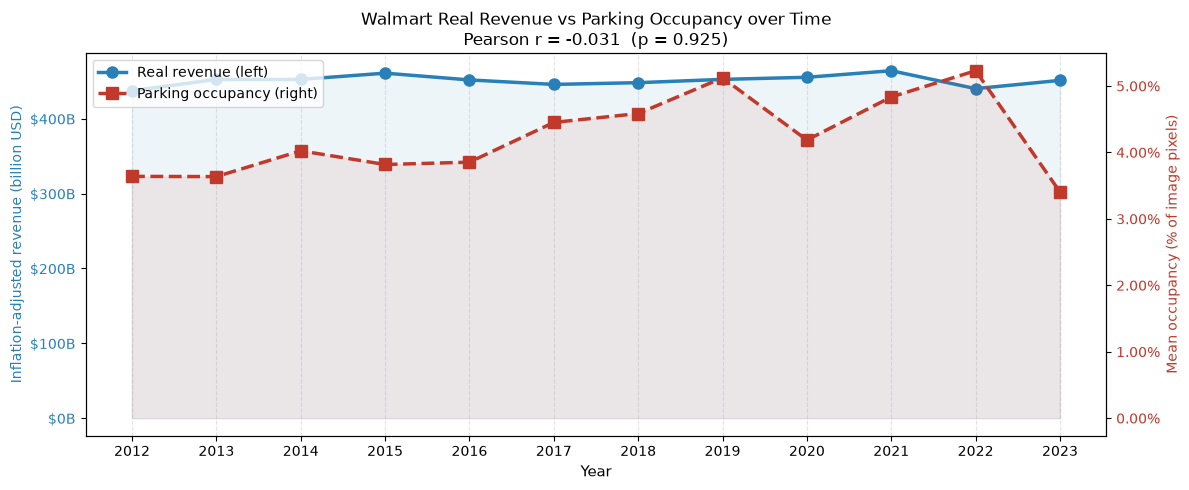

In [127]:
fig, ax1 = plt.subplots(figsize=(12, 5))

color_rev = "#2980b9"
color_occ = "#c0392b"

ax1.plot(df_merged["year"], df_merged["revenue_real"] / 1_000,
         color=color_rev, marker="o", linewidth=2.5, markersize=8, label="Real revenue (left)")
ax1.fill_between(df_merged["year"], df_merged["revenue_real"] / 1_000,
                 alpha=0.08, color=color_rev)
ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("Inflation-adjusted revenue (billion USD)", fontsize=10, color=color_rev)
ax1.tick_params(axis="y", labelcolor=color_rev)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y:.0f}B"))

ax2 = ax1.twinx()
ax2.plot(df_merged["year"], df_merged["occ_pct"],
         color=color_occ, marker="s", linewidth=2.5, markersize=8,
         linestyle="--", label="Parking occupancy (right)")
ax2.fill_between(df_merged["year"], df_merged["occ_pct"],
                 alpha=0.08, color=color_occ)
ax2.set_ylabel("Mean occupancy (% of image pixels)", fontsize=10, color=color_occ)
ax2.tick_params(axis="y", labelcolor=color_occ)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}%"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="upper left")

ax1.set_xticks(df_merged["year"])
ax1.grid(axis="x", linestyle="--", alpha=0.35)
plt.title(
    f"Walmart Real Revenue vs Parking Occupancy over Time\n"
    f"Pearson r = {r:+.3f}  (p = {p:.3f})",
    fontsize=12
)
plt.tight_layout()
plt.show()

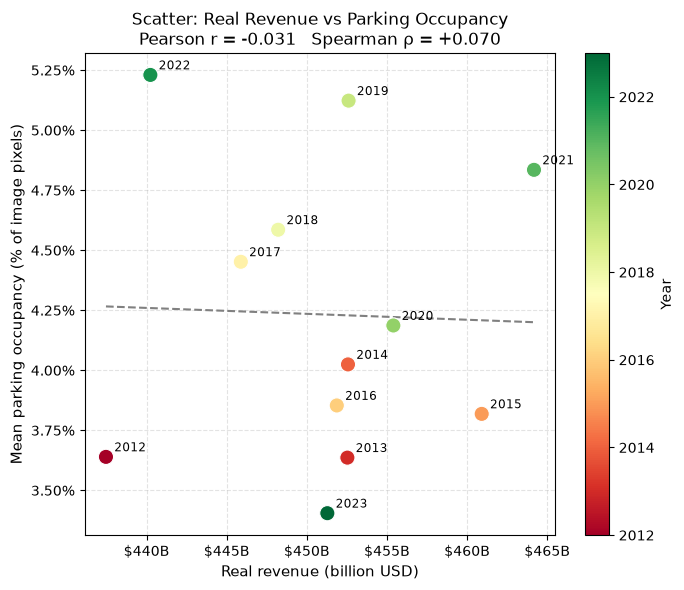

In [128]:
fig, ax = plt.subplots(figsize=(7, 6))

sc = ax.scatter(
    df_merged["revenue_real"] / 1_000,
    df_merged["occ_pct"],
    c=df_merged["year"], cmap="RdYlGn",
    s=120, edgecolors="white", linewidths=0.8, zorder=3
)
for _, row in df_merged.iterrows():
    ax.annotate(
        str(int(row["year"])),
        (row["revenue_real"] / 1_000, row["occ_pct"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8.5
    )

# OLS trend line
x = df_merged["revenue_real"] / 1_000
m, b = np.polyfit(x, df_merged["occ_pct"], 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color="grey", linewidth=1.5, linestyle="--", zorder=2)

plt.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("Real revenue (billion USD)", fontsize=11)
ax.set_ylabel("Mean parking occupancy (% of image pixels)", fontsize=11)
ax.set_title(
    f"Scatter: Real Revenue vs Parking Occupancy\n"
    f"Pearson r = {r:+.3f}   Spearman ρ = {rho:+.3f}",
    fontsize=12
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y:.0f}B"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f}%"))
ax.grid(linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

## 5 · Year-over-Year Growth Rates — Correlation of % Δ Revenue vs % Δ Occupancy

Working with **levels** (Section 2–3) risks spurious correlation driven by shared long-run trends.

A cleaner test differences both series as **year-over-year growth rates (%)**, putting them in the same unit:

`% Δ revenue_real  = (revenue_real(t) − revenue_real(t−1)) / revenue_real(t−1) × 100`  
`% Δ occupancy     = (occ_pct(t) − occ_pct(t−1)) / occ_pct(t−1) × 100`

Both are now dimensionless percentage changes — directly comparable.

In [129]:
df_diff = df_merged.copy().sort_values("year").reset_index(drop=True)

# YoY growth rates (%) — same unit for both series
df_diff["pct_delta_revenue"] = df_diff["revenue_real"].pct_change() * 100
df_diff["pct_delta_occ"]     = df_diff["occ_pct"].pct_change()     * 100
df_diff = df_diff.dropna(subset=["pct_delta_revenue", "pct_delta_occ"])

print(f"{'Year':>6}  {'% Δ Revenue':>13}  {'% Δ Occupancy':>15}")
print("─" * 40)
for _, row in df_diff.iterrows():
    print(f"{int(row.year):>6}  {row.pct_delta_revenue:>+12.2f}%  {row.pct_delta_occ:>+14.2f}%")

r_d,   p_d  = stats.pearsonr(df_diff["pct_delta_revenue"], df_diff["pct_delta_occ"])
rho_d, p_sd = stats.spearmanr(df_diff["pct_delta_revenue"], df_diff["pct_delta_occ"])

print(f"\nPearson  r  = {r_d:+.4f}   p = {p_d:.4f}  {'*** p<0.01' if p_d<0.01 else '** p<0.05' if p_d<0.05 else '* p<0.10' if p_d<0.10 else 'n.s.'}")
print(f"Spearman ρ  = {rho_d:+.4f}   p = {p_sd:.4f}  {'*** p<0.01' if p_sd<0.01 else '** p<0.05' if p_sd<0.05 else '* p<0.10' if p_sd<0.10 else 'n.s.'}")
print(f"n = {len(df_diff)} year-over-year transitions")

  Year    % Δ Revenue    % Δ Occupancy
────────────────────────────────────────
  2013         +3.44%           -0.09%
  2014         +0.01%          +10.68%
  2015         +1.84%           -5.12%
  2016         -1.96%           +0.92%
  2017         -1.33%          +15.53%
  2018         +0.52%           +3.00%
  2019         +0.98%          +11.72%
  2020         +0.62%          -18.28%
  2021         +1.93%          +15.48%
  2022         -5.16%           +8.18%
  2023         +2.51%          -34.90%

Pearson  r  = -0.3559   p = 0.2828  n.s.
Spearman ρ  = -0.3727   p = 0.2589  n.s.
n = 11 year-over-year transitions


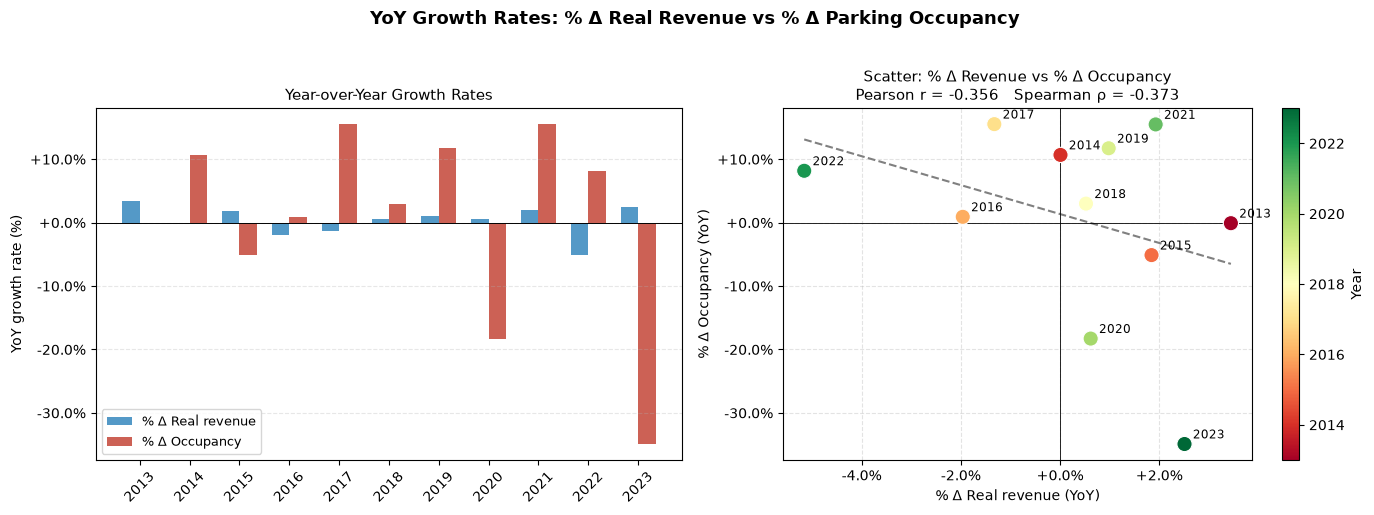

In [130]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: grouped bars, both series in % ────────────────────────────────────
ax = axes[0]
width = 0.35
years = df_diff["year"].values
x     = np.arange(len(years))

ax.bar(x - width/2, df_diff["pct_delta_revenue"], width,
       color="#2980b9", alpha=0.8, label="% Δ Real revenue")
ax.bar(x + width/2, df_diff["pct_delta_occ"], width,
       color="#c0392b", alpha=0.8, label="% Δ Occupancy")

ax.axhline(0, color="black", linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(years.astype(int), rotation=45)
ax.set_ylabel("YoY growth rate (%)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.legend(fontsize=9)
ax.set_title("Year-over-Year Growth Rates", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# ── Right: scatter % Δ revenue vs % Δ occupancy ─────────────────────────────
ax = axes[1]
sc = ax.scatter(
    df_diff["pct_delta_revenue"],
    df_diff["pct_delta_occ"],
    c=df_diff["year"], cmap="RdYlGn",
    s=120, edgecolors="white", linewidths=0.8, zorder=3
)
for _, row in df_diff.iterrows():
    ax.annotate(
        str(int(row["year"])),
        (row["pct_delta_revenue"], row["pct_delta_occ"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8.5
    )

xv = df_diff["pct_delta_revenue"]
m, b = np.polyfit(xv, df_diff["pct_delta_occ"], 1)
xl = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xl, m * xl + b, color="grey", linewidth=1.5, linestyle="--", zorder=2)

ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
plt.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("% Δ Real revenue (YoY)", fontsize=10)
ax.set_ylabel("% Δ Occupancy (YoY)", fontsize=10)
ax.set_title(
    f"Scatter: % Δ Revenue vs % Δ Occupancy\n"
    f"Pearson r = {r_d:+.3f}   Spearman ρ = {rho_d:+.3f}",
    fontsize=11
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.grid(linestyle="--", alpha=0.35)

plt.suptitle(
    "YoY Growth Rates: % Δ Real Revenue vs % Δ Parking Occupancy",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

### Why the differenced correlation matters\n\nCorrelating **levels** (Section 2–3) answers: *are higher-revenue years also higher-occupancy years?* — but both series can trend together simply because time passes, not because they are causally linked.\n\nCorrelating **first differences** (Section 5) answers: *does revenue growing faster than usual coincide with occupancy growing faster than usual?* This removes the shared time trend and is a more demanding test of co-movement.\n\n| | Pearson r | Spearman ρ |\n|---|---|---|\n| Levels | from Section 2 | from Section 2 |\n| First differences | from Section 5 | from Section 5 |\n\nIf the differenced correlation is weak even when the levels correlation looks strong, it is evidence that the relationship in levels is driven by a common trend rather than genuine co-movement.

---

## 6 · YoY Correlation — Outlier Stores Removed (P10–P90 Intra-Store Variation)

Stores whose **intra-store occupancy variation** (std dev of occupancy across all their observations) falls below P10 or above P90 are excluded before recomputing the annual mean. This removes:
- **Below P10** — nearly flat stores that barely change over time (no signal)
- **Above P90** — wildly volatile stores that dominate the aggregate with noise

The filtered annual occupancy series is then differenced and correlated with Δ real revenue, mirroring Section 5.

In [131]:
# ── Intra-store variation: std dev across all observations per store ────────
store_var = (
    df_occ.groupby("store_id")["occupancy"]
    .std()
    .dropna()                           # needs ≥2 observations
    .rename("intra_std")
)

p10 = store_var.quantile(0.10)
p90 = store_var.quantile(0.90)

stores_clean = store_var[(store_var >= p10) & (store_var <= p90)].index
df_occ_clean = df_occ[df_occ["store_id"].isin(stores_clean)]

print(f"Intra-store variation (std dev across time)")
print(f"  P10 = {p10:.4f}  ({p10*100:.3f}%)")
print(f"  P90 = {p90:.4f}  ({p90*100:.3f}%)")
print(f"  Stores total     : {len(store_var)}")
print(f"  Stores kept      : {len(stores_clean)}")
print(f"  Stores removed   : {len(store_var) - len(stores_clean)}")

# ── Annual mean on filtered stores ──────────────────────────────────────────
occ_annual_clean = (
    df_occ_clean.groupby("year")["occupancy"]
    .agg(occ_mean="mean", occ_std="std", n_images="count")
    .reset_index()
)
occ_annual_clean["occ_pct"] = occ_annual_clean["occ_mean"] * 100

# ── Merge with deflated revenue ──────────────────────────────────────────────
df_merged_clean = pd.merge(df[["year", "revenue", "revenue_real"]], occ_annual_clean, on="year")

print(f"\nOverlapping years after filter: {df_merged_clean['year'].min()}–{df_merged_clean['year'].max()}  ({len(df_merged_clean)} points)")
print(f"\n{'Year':>6}  {'N stores (images)':>18}  {'Mean occ':>10}")
print("─" * 40)
for _, row in df_merged_clean.iterrows():
    print(f"{int(row.year):>6}  {int(row.n_images):>18}  {row.occ_pct:>9.4f}%")

Intra-store variation (std dev across time)
  P10 = 0.0074  (0.741%)
  P90 = 0.0254  (2.544%)
  Stores total     : 95
  Stores kept      : 75
  Stores removed   : 20

Overlapping years after filter: 2012–2023  (12 points)

  Year   N stores (images)    Mean occ
────────────────────────────────────────
  2012                  26     3.9680%
  2013                  36     3.5770%
  2014                  28     4.3107%
  2015                  32     3.5823%
  2016                  27     4.0905%
  2017                  32     3.8228%
  2018                  36     4.8974%
  2019                  26     4.7789%
  2020                  23     4.5459%
  2021                  39     4.7461%
  2022                  29     5.1873%
  2023                  49     3.6213%


In [132]:
df_diff_clean = df_merged_clean.sort_values("year").reset_index(drop=True)

# YoY growth rates (%) — same unit for both series
df_diff_clean["pct_delta_revenue"] = df_diff_clean["revenue_real"].pct_change() * 100
df_diff_clean["pct_delta_occ"]     = df_diff_clean["occ_pct"].pct_change()     * 100
df_diff_clean = df_diff_clean.dropna(subset=["pct_delta_revenue", "pct_delta_occ"])

r_c,   p_c  = stats.pearsonr(df_diff_clean["pct_delta_revenue"], df_diff_clean["pct_delta_occ"])
rho_c, p_sc = stats.spearmanr(df_diff_clean["pct_delta_revenue"], df_diff_clean["pct_delta_occ"])

print(f"{'Year':>6}  {'% Δ Revenue':>13}  {'% Δ Occupancy':>15}")
print("─" * 40)
for _, row in df_diff_clean.iterrows():
    print(f"{int(row.year):>6}  {row.pct_delta_revenue:>+12.2f}%  {row.pct_delta_occ:>+14.2f}%")

print(f"\nPearson  r  = {r_c:+.4f}   p = {p_c:.4f}  {'*** p<0.01' if p_c<0.01 else '** p<0.05' if p_c<0.05 else '* p<0.10' if p_c<0.10 else 'n.s.'}")
print(f"Spearman ρ  = {rho_c:+.4f}   p = {p_sc:.4f}  {'*** p<0.01' if p_sc<0.01 else '** p<0.05' if p_sc<0.05 else '* p<0.10' if p_sc<0.10 else 'n.s.'}")
print(f"n = {len(df_diff_clean)} transitions")

print(f"\nComparison with unfiltered (Section 5):")
print(f"  Pearson  r : {r_d:+.4f} → {r_c:+.4f}  (Δ = {r_c - r_d:+.4f})")
print(f"  Spearman ρ : {rho_d:+.4f} → {rho_c:+.4f}  (Δ = {rho_c - rho_d:+.4f})")

  Year    % Δ Revenue    % Δ Occupancy
────────────────────────────────────────
  2013         +3.44%           -9.86%
  2014         +0.01%          +20.51%
  2015         +1.84%          -16.90%
  2016         -1.96%          +14.19%
  2017         -1.33%           -6.55%
  2018         +0.52%          +28.11%
  2019         +0.98%           -2.42%
  2020         +0.62%           -4.88%
  2021         +1.93%           +4.40%
  2022         -5.16%           +9.30%
  2023         +2.51%          -30.19%

Pearson  r  = -0.4689   p = 0.1457  n.s.
Spearman ρ  = -0.6273   p = 0.0388  ** p<0.05
n = 11 transitions

Comparison with unfiltered (Section 5):
  Pearson  r : -0.3559 → -0.4689  (Δ = -0.1130)
  Spearman ρ : -0.3727 → -0.6273  (Δ = -0.2545)


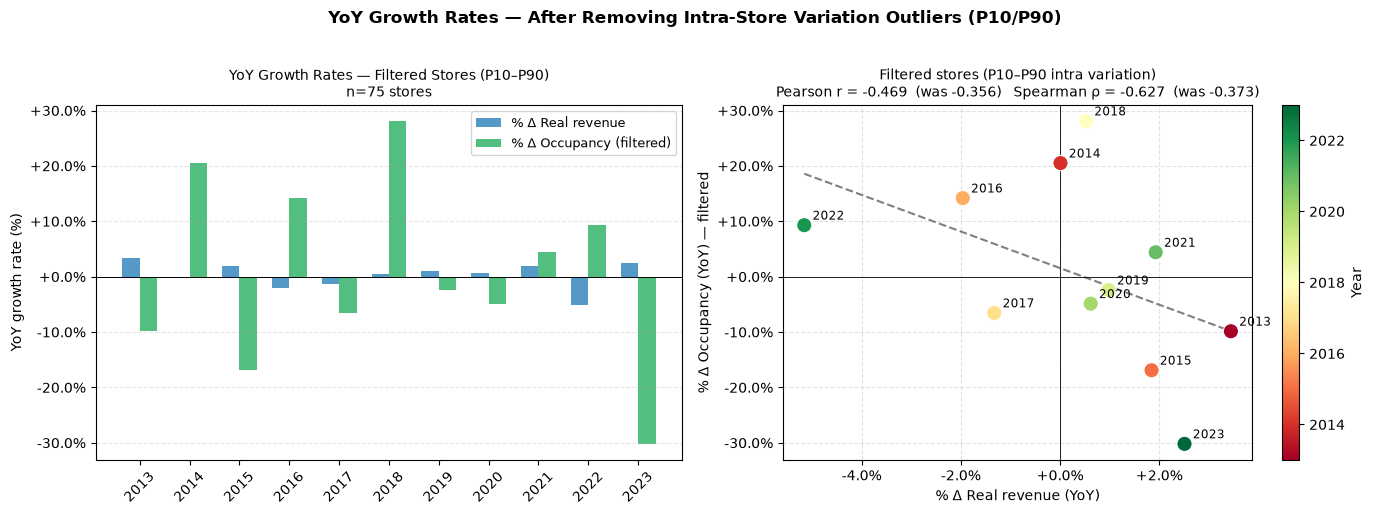

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: grouped bars, both in % ───────────────────────────────────────────
ax = axes[0]
width = 0.35
years = df_diff_clean["year"].values
x     = np.arange(len(years))

ax.bar(x - width/2, df_diff_clean["pct_delta_revenue"], width,
       color="#2980b9", alpha=0.8, label="% Δ Real revenue")
ax.bar(x + width/2, df_diff_clean["pct_delta_occ"], width,
       color="#27ae60", alpha=0.8, label="% Δ Occupancy (filtered)")

ax.axhline(0, color="black", linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(years.astype(int), rotation=45)
ax.set_ylabel("YoY growth rate (%)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.legend(fontsize=9)
ax.set_title(f"YoY Growth Rates — Filtered Stores (P10–P90)\nn={len(stores_clean)} stores", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# ── Right: scatter ───────────────────────────────────────────────────────────
ax = axes[1]
sc = ax.scatter(
    df_diff_clean["pct_delta_revenue"],
    df_diff_clean["pct_delta_occ"],
    c=df_diff_clean["year"], cmap="RdYlGn",
    s=120, edgecolors="white", linewidths=0.8, zorder=3
)
for _, row in df_diff_clean.iterrows():
    ax.annotate(
        str(int(row["year"])),
        (row["pct_delta_revenue"], row["pct_delta_occ"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8.5
    )

xv = df_diff_clean["pct_delta_revenue"]
m, b = np.polyfit(xv, df_diff_clean["pct_delta_occ"], 1)
xl = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xl, m * xl + b, color="grey", linewidth=1.5, linestyle="--", zorder=2)

ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
plt.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("% Δ Real revenue (YoY)", fontsize=10)
ax.set_ylabel("% Δ Occupancy (YoY) — filtered", fontsize=10)
ax.set_title(
    f"Filtered stores (P10–P90 intra variation)\n"
    f"Pearson r = {r_c:+.3f}  (was {r_d:+.3f})   "
    f"Spearman ρ = {rho_c:+.3f}  (was {rho_d:+.3f})",
    fontsize=10
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.grid(linestyle="--", alpha=0.35)

plt.suptitle(
    "YoY Growth Rates — After Removing Intra-Store Variation Outliers (P10/P90)",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

---

## 7 · Seasonal Adjustment

NAIP images are taken at different months each year. If 2018 happens to have more summer images than 2015, the annual occupancy average is higher for a purely seasonal reason — not because more cars were actually there.

**Fix:** divide each image's occupancy by the average occupancy for that calendar month (computed across all years and stores), then rescale back to the original mean. This removes the month-of-year effect before aggregating to annual averages.

`occ_adj = (occ / monthly_mean_for_that_month) × global_mean`

Values above the global mean → above what you'd expect for that month. Values below → below expectations. Aggregating these gives an annual series where the composition of months no longer drives the result.

In [134]:
# ── Build seasonal index ────────────────────────────────────────────────────
df_occ["month"] = df_occ["date"].dt.month

monthly_mean  = df_occ.groupby("month")["occupancy"].mean().rename("month_mean")
global_mean   = df_occ["occupancy"].mean()

df_occ_adj = df_occ.merge(monthly_mean, on="month")
df_occ_adj["occ_adj"] = (df_occ_adj["occupancy"] / df_occ_adj["month_mean"]) * global_mean

print("Monthly seasonal index (mean occupancy by month across all years & stores)\n")
print(f"  Global mean : {global_mean*100:.4f}%\n")
print(f"  {'Month':>6}  {'Raw mean':>10}  {'Index':>8}  {'N images':>9}")
print("  " + "─" * 40)
for month, grp in df_occ.groupby("month"):
    mu  = grp["occupancy"].mean()
    idx = mu / global_mean
    print(f"  {month:>6}  {mu*100:>9.4f}%  {idx:>8.3f}  {len(grp):>9}")

# ── Sanity check: adjusted global mean should equal original global mean ────
print(f"\n  Adjusted global mean : {df_occ_adj['occ_adj'].mean()*100:.4f}%  (should equal {global_mean*100:.4f}%)")

Monthly seasonal index (mean occupancy by month across all years & stores)

  Global mean : 4.3050%

   Month    Raw mean     Index   N images
  ────────────────────────────────────────
       1     3.7216%     0.864          1
       2     3.3447%     0.777          1
       4     4.4158%     1.026         14
       5     5.5745%     1.295         38
       6     4.4013%     1.022         98
       7     4.2641%     0.990        144
       8     3.9641%     0.921        115
       9     3.8841%     0.902         73
      10     3.8964%     0.905         45
      11     5.5239%     1.283         27
      12     5.5135%     1.281          3

  Adjusted global mean : 4.3050%  (should equal 4.3050%)


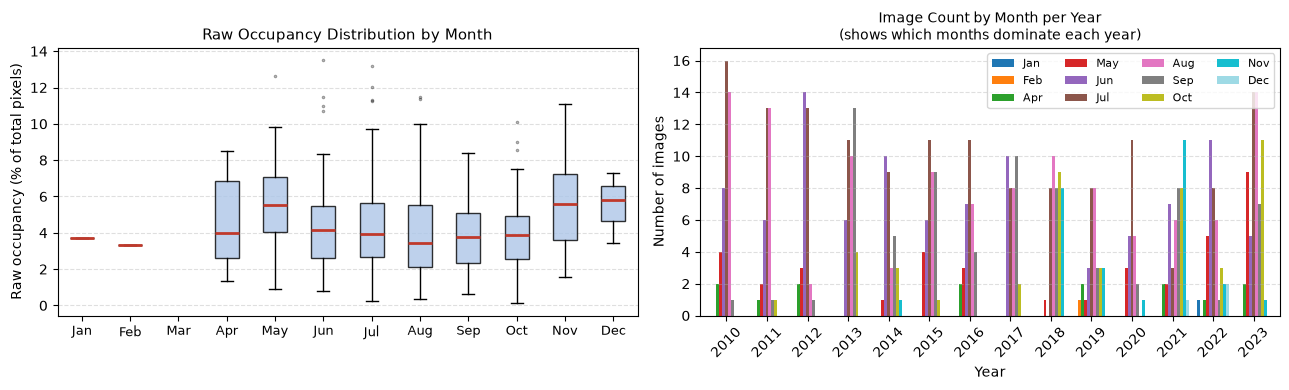

In [135]:
# ── Visualise the seasonal pattern ─────────────────────────────────────────
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw occupancy by month (box plot)
ax = axes[0]
data_by_month = [df_occ[df_occ["month"] == m]["occupancy"].values * 100
                 for m in range(1, 13)]
bp = ax.boxplot(data_by_month, patch_artist=True,
                boxprops=dict(facecolor="#aec6e8", alpha=0.8),
                medianprops=dict(color="#c0392b", linewidth=2),
                flierprops=dict(marker=".", markersize=3, alpha=0.4))
ax.set_xticklabels(month_names, fontsize=9)
ax.set_ylabel("Raw occupancy (% of total pixels)", fontsize=10)
ax.set_title("Raw Occupancy Distribution by Month", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Right: image count per month per year (heatmap-style bar)
ax = axes[1]
month_year_counts = df_occ.groupby(["year", "month"]).size().unstack(fill_value=0)
month_year_counts.plot(kind="bar", ax=ax, colormap="tab20",
                       width=0.8, legend=False)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Number of images", fontsize=10)
ax.set_title("Image Count by Month per Year\n(shows which months dominate each year)", fontsize=10)
ax.set_xticklabels(month_year_counts.index.astype(int), rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.4)
# compact legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [month_names[int(l)-1] for l in labels],
          ncol=4, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

In [136]:
# ── Annual mean on seasonally-adjusted occupancy ────────────────────────────
occ_annual_adj = (
    df_occ_adj.groupby("year")["occ_adj"]
    .agg(occ_mean="mean", occ_std="std", n_images="count")
    .reset_index()
)
occ_annual_adj["occ_pct"] = occ_annual_adj["occ_mean"] * 100

df_merged_adj = pd.merge(df[["year", "revenue", "revenue_real"]], occ_annual_adj, on="year")

# ── YoY growth rates ────────────────────────────────────────────────────────
df_diff_adj = df_merged_adj.sort_values("year").reset_index(drop=True)
df_diff_adj["pct_delta_revenue"] = df_diff_adj["revenue_real"].pct_change() * 100
df_diff_adj["pct_delta_occ"]     = df_diff_adj["occ_pct"].pct_change()     * 100
df_diff_adj = df_diff_adj.dropna(subset=["pct_delta_revenue", "pct_delta_occ"])

r_adj,   p_adj  = stats.pearsonr(df_diff_adj["pct_delta_revenue"], df_diff_adj["pct_delta_occ"])
rho_adj, p_sadj = stats.spearmanr(df_diff_adj["pct_delta_revenue"], df_diff_adj["pct_delta_occ"])

print(f"{'Year':>6}  {'% Δ Revenue':>13}  {'% Δ Occ (adj)':>15}")
print("─" * 40)
for _, row in df_diff_adj.iterrows():
    print(f"{int(row.year):>6}  {row.pct_delta_revenue:>+12.2f}%  {row.pct_delta_occ:>+14.2f}%")

print(f"\nSeasonally adjusted")
print(f"  Pearson  r  = {r_adj:+.4f}   p = {p_adj:.4f}  {'*** p<0.01' if p_adj<0.01 else '** p<0.05' if p_adj<0.05 else '* p<0.10' if p_adj<0.10 else 'n.s.'}")
print(f"  Spearman ρ  = {rho_adj:+.4f}   p = {p_sadj:.4f}  {'*** p<0.01' if p_sadj<0.01 else '** p<0.05' if p_sadj<0.05 else '* p<0.10' if p_sadj<0.10 else 'n.s.'}")
print(f"\nComparison with unadjusted (Section 5)")
print(f"  Pearson  r : {r_d:+.4f} → {r_adj:+.4f}  (Δ = {r_adj - r_d:+.4f})")
print(f"  Spearman ρ : {rho_d:+.4f} → {rho_adj:+.4f}  (Δ = {rho_adj - rho_d:+.4f})")

  Year    % Δ Revenue    % Δ Occ (adj)
────────────────────────────────────────
  2013         +3.44%           +7.69%
  2014         +0.01%           +5.89%
  2015         +1.84%           -5.89%
  2016         -1.96%           +1.76%
  2017         -1.33%          +18.58%
  2018         +0.52%           -1.82%
  2019         +0.98%          +16.07%
  2020         +0.62%          -23.20%
  2021         +1.93%          +16.01%
  2022         -5.16%           +6.47%
  2023         +2.51%          -31.82%

Seasonally adjusted
  Pearson  r  = -0.2515   p = 0.4557  n.s.
  Spearman ρ  = -0.1545   p = 0.6500  n.s.

Comparison with unadjusted (Section 5)
  Pearson  r : -0.3559 → -0.2515  (Δ = +0.1044)
  Spearman ρ : -0.3727 → -0.1545  (Δ = +0.2182)


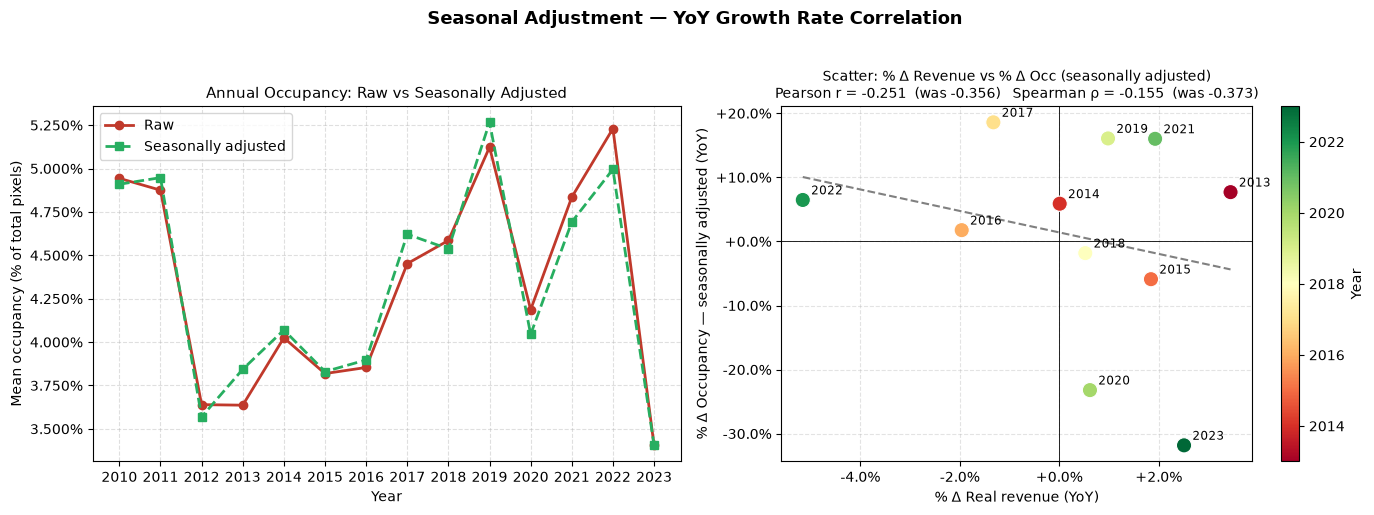

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: raw vs adjusted annual occupancy ───────────────────────────────────
ax = axes[0]
ax.plot(occ_annual["year"],     occ_annual["occ_pct"],
        marker="o", linewidth=2, color="#c0392b", label="Raw")
ax.plot(occ_annual_adj["year"], occ_annual_adj["occ_pct"],
        marker="s", linewidth=2, color="#27ae60", linestyle="--", label="Seasonally adjusted")
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Mean occupancy (% of total pixels)", fontsize=10)
ax.set_title("Annual Occupancy: Raw vs Seasonally Adjusted", fontsize=11)
ax.set_xticks(occ_annual["year"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.3f}%"))
ax.legend(fontsize=10)
ax.grid(linestyle="--", alpha=0.4)

# ── Right: scatter % Δ revenue vs % Δ occ (adjusted) ────────────────────────
ax = axes[1]
sc = ax.scatter(
    df_diff_adj["pct_delta_revenue"],
    df_diff_adj["pct_delta_occ"],
    c=df_diff_adj["year"], cmap="RdYlGn",
    s=120, edgecolors="white", linewidths=0.8, zorder=3
)
for _, row in df_diff_adj.iterrows():
    ax.annotate(
        str(int(row["year"])),
        (row["pct_delta_revenue"], row["pct_delta_occ"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8.5
    )

xv = df_diff_adj["pct_delta_revenue"]
m, b = np.polyfit(xv, df_diff_adj["pct_delta_occ"], 1)
xl = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xl, m * xl + b, color="grey", linewidth=1.5, linestyle="--", zorder=2)

ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
plt.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("% Δ Real revenue (YoY)", fontsize=10)
ax.set_ylabel("% Δ Occupancy — seasonally adjusted (YoY)", fontsize=10)
ax.set_title(
    f"Scatter: % Δ Revenue vs % Δ Occ (seasonally adjusted)\n"
    f"Pearson r = {r_adj:+.3f}  (was {r_d:+.3f})   "
    f"Spearman ρ = {rho_adj:+.3f}  (was {rho_d:+.3f})",
    fontsize=10
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.grid(linestyle="--", alpha=0.35)

plt.suptitle(
    "Seasonal Adjustment — YoY Growth Rate Correlation",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

---

## 8 · Quarterly Matching

Instead of aggregating images to annual averages, each image is assigned to its **nearest Walmart fiscal quarter-end** (Jan 31 / Apr 30 / Jul 31 / Oct 31) and occupancy is averaged within that quarter.

YoY growth rates are then computed as **same-quarter year-over-year** (`pct_change(periods=4)`), which naturally controls for seasonality without needing a separate adjustment — Q3-2019 is always compared to Q3-2018.

This also gives ~4× more data points than the annual approach.

In [138]:
# ── Load & deflate quarterly revenue ───────────────────────────────────────
df_q = pd.read_csv(DATA / "walmart_quarterly_revenue.csv", parse_dates=["date"])
df_q = df_q.sort_values("date").reset_index(drop=True)
df_q["year"] = df_q["date"].dt.year

# Attach annual CPI by calendar year and compute cumulative deflator
df_q = df_q.merge(df_cpi, on="year", how="left")
df_q["cpi_mult"] = 1 + df_q["inflation"] / 100
# quarterly cumulative index: compound annually, approximate uniformly within year
# use the cumulative product from the annual series (anchor = first year in sample)
annual_cum = df[["year", "cpi_cumulative"]].copy()
df_q = df_q.merge(annual_cum, on="year", how="left")
df_q["revenue_real_q"] = (df_q["revenue"] / df_q["cpi_cumulative"]).round(0)

# keep only quarters that overlap with occupancy data and have CPI available
df_q = df_q.dropna(subset=["revenue_real_q"])

# ── Match each image to its nearest quarter-end ─────────────────────────────
quarter_ends = df_q["date"].values  # already sorted

def nearest_quarter_end(d):
    diffs = np.abs(quarter_ends - np.datetime64(d))
    return pd.Timestamp(quarter_ends[diffs.argmin()])

df_occ["quarter_end"] = df_occ["date"].apply(nearest_quarter_end)

# ── Aggregate occupancy per quarter ─────────────────────────────────────────
occ_quarterly = (
    df_occ.groupby("quarter_end")["occupancy"]
    .agg(occ_mean="mean", n_images="count")
    .reset_index()
)
occ_quarterly["occ_pct"] = occ_quarterly["occ_mean"] * 100

# ── Merge with quarterly revenue ─────────────────────────────────────────────
df_q_merged = pd.merge(
    df_q[["date", "revenue_real_q"]],
    occ_quarterly,
    left_on="date", right_on="quarter_end"
).sort_values("date").reset_index(drop=True)

# ── Same-quarter YoY growth rates (shift 4 periods = 1 year) ────────────────
df_q_merged["pct_delta_revenue"] = df_q_merged["revenue_real_q"].pct_change(periods=4) * 100
df_q_merged["pct_delta_occ"]     = df_q_merged["occ_pct"].pct_change(periods=4)       * 100
df_q_diff = df_q_merged.dropna(subset=["pct_delta_revenue", "pct_delta_occ"])

r_q,   p_q  = stats.pearsonr(df_q_diff["pct_delta_revenue"], df_q_diff["pct_delta_occ"])
rho_q, p_sq = stats.spearmanr(df_q_diff["pct_delta_revenue"], df_q_diff["pct_delta_occ"])

print(f"Quarters with occupancy data : {len(occ_quarterly)}")
print(f"Quarters after YoY shift     : {len(df_q_diff)}  (usable observations)\n")
print(f"{'Quarter':>12}  {'% Δ Revenue':>13}  {'% Δ Occ':>10}  {'N images':>9}")
print("─" * 52)
for _, row in df_q_diff.iterrows():
    print(f"{str(row.date.date()):>12}  {row.pct_delta_revenue:>+12.2f}%  {row.pct_delta_occ:>+9.2f}%  {int(row.n_images):>9}")

print(f"\nPearson  r  = {r_q:+.4f}   p = {p_q:.4f}  {'*** p<0.01' if p_q<0.01 else '** p<0.05' if p_q<0.05 else '* p<0.10' if p_q<0.10 else 'n.s.'}")
print(f"Spearman ρ  = {rho_q:+.4f}   p = {p_sq:.4f}  {'*** p<0.01' if p_sq<0.01 else '** p<0.05' if p_sq<0.05 else '* p<0.10' if p_sq<0.10 else 'n.s.'}")
print(f"\nvs annual unadjusted (Section 5):  r = {r_d:+.4f}  ρ = {rho_d:+.4f}")

Quarters with occupancy data : 39
Quarters after YoY shift     : 35  (usable observations)

     Quarter    % Δ Revenue     % Δ Occ   N images
────────────────────────────────────────────────────
  2013-07-31         -6.18%     -36.05%         28
  2013-10-31         +0.89%      +4.85%         11
  2014-04-30         -2.44%     +52.21%          6
  2014-07-31         +3.63%     -34.30%         19
  2014-10-31         +0.23%      +2.18%          7
  2015-04-30         -2.44%     +46.76%          7
  2015-07-31         +4.46%     -39.23%         28
  2015-10-31         -2.38%      +0.72%          5
  2016-04-30         -3.93%      -1.10%         10
  2016-07-31         +3.94%     -27.26%         21
  2016-10-31         -2.93%     +23.31%          3
  2017-04-30         -3.19%     +66.90%          6
  2017-07-31         +4.21%     +32.15%         27
  2017-10-31         -0.20%     -18.11%          5
  2018-04-30         -0.77%     +79.71%          1
  2018-07-31         +6.32%     -29.40%

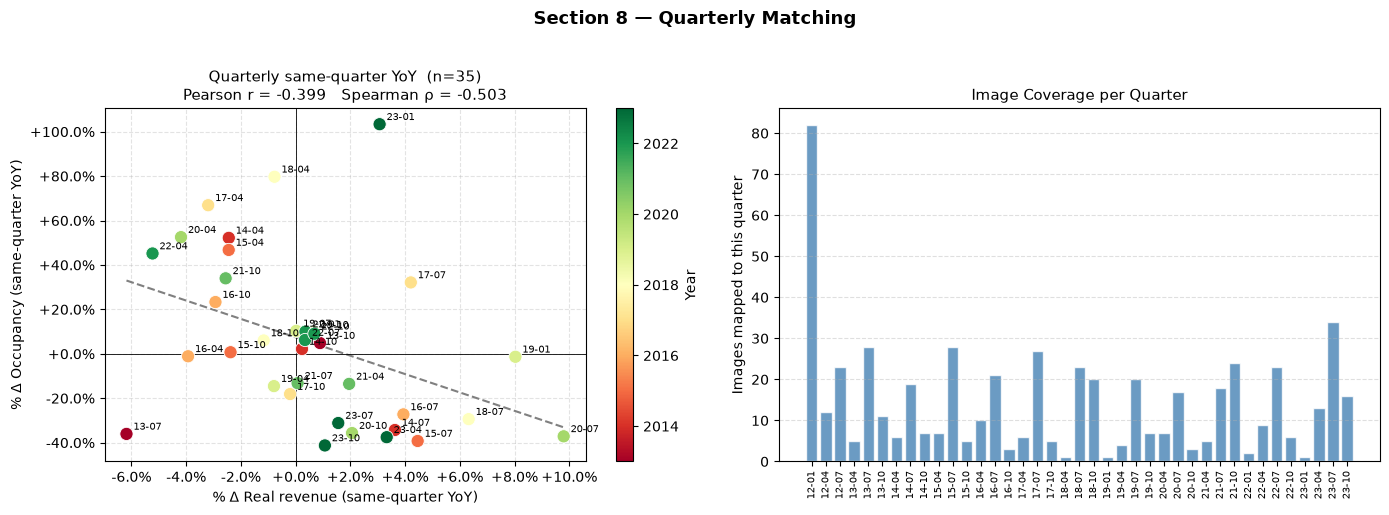

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: scatter quarterly YoY ─────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(
    df_q_diff["pct_delta_revenue"],
    df_q_diff["pct_delta_occ"],
    c=df_q_diff["date"].dt.year, cmap="RdYlGn",
    s=90, edgecolors="white", linewidths=0.6, zorder=3
)
for _, row in df_q_diff.iterrows():
    ax.annotate(
        str(row["date"].date())[2:7],   # "YY-MM"
        (row["pct_delta_revenue"], row["pct_delta_occ"]),
        textcoords="offset points", xytext=(5, 3), fontsize=7
    )
xv = df_q_diff["pct_delta_revenue"]
m, b = np.polyfit(xv, df_q_diff["pct_delta_occ"], 1)
xl = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xl, m * xl + b, color="grey", linewidth=1.5, linestyle="--")
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
plt.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("% Δ Real revenue (same-quarter YoY)", fontsize=10)
ax.set_ylabel("% Δ Occupancy (same-quarter YoY)", fontsize=10)
ax.set_title(
    f"Quarterly same-quarter YoY  (n={len(df_q_diff)})\n"
    f"Pearson r = {r_q:+.3f}   Spearman ρ = {rho_q:+.3f}",
    fontsize=11
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.grid(linestyle="--", alpha=0.35)

# ── Right: n images per quarter (shows coverage) ────────────────────────────
ax = axes[1]
ax.bar(range(len(occ_quarterly)),
       occ_quarterly["n_images"],
       color="steelblue", edgecolor="white", alpha=0.8)
ax.set_xticks(range(len(occ_quarterly)))
ax.set_xticklabels(
    [str(d.date())[2:7] for d in occ_quarterly["quarter_end"]],
    rotation=90, fontsize=7
)
ax.set_ylabel("Images mapped to this quarter", fontsize=10)
ax.set_title("Image Coverage per Quarter", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Section 8 — Quarterly Matching", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

## 9 · Lag Analysis

Tests whether the relationship between occupancy and revenue is **contemporaneous or shifted in time**:

- `lag = -1` → occupancy *leads* revenue by 1 year (parking visits now predict sales next year)
- `lag = 0`  → contemporaneous (both measured in the same year)
- `lag = +1` → revenue *leads* occupancy by 1 year (revenue growth brings more visitors later)

Uses the seasonally-adjusted annual occupancy series from Section 7.

  Lag          Direction   Pearson r        p   Spearman ρ        p     n
────────────────────────────────────────────────────────────────────────
   -2      occ leads rev     -0.1946   0.5901         -0.1515   0.6761       10
   -1      occ leads rev     +0.3884   0.2378         +0.3182   0.3403       11
    0    contemporaneous     -0.0113   0.9721         +0.1119   0.7292       12 ◄
    1      rev leads occ     -0.1737   0.6095         -0.0727   0.8317       11
    2      rev leads occ     +0.4818   0.1586         +0.3576   0.3104       10


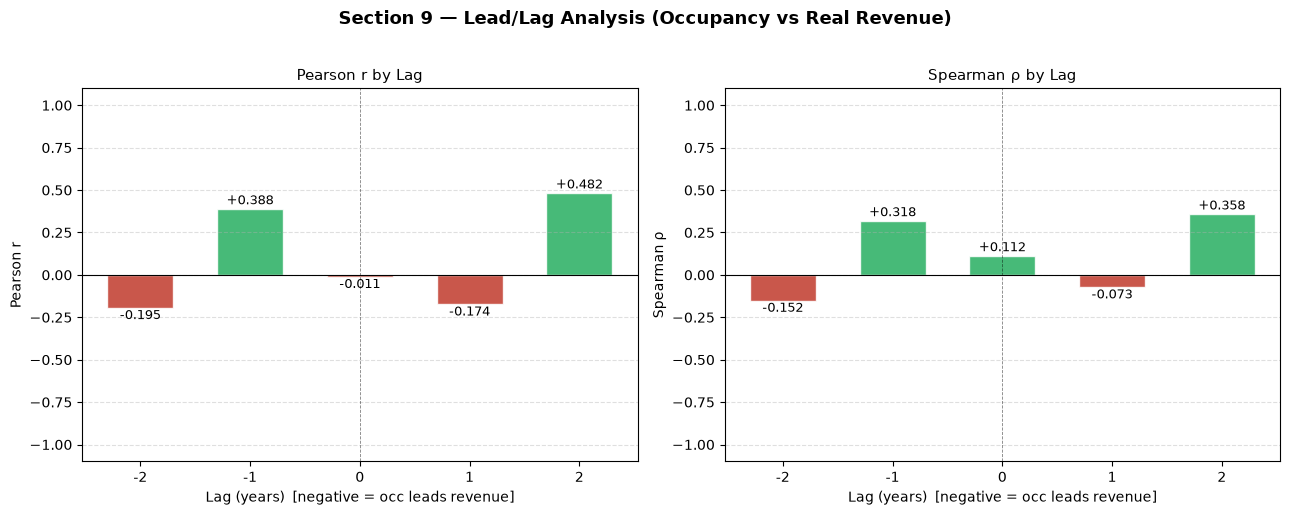

In [140]:
# Base series: seasonally adjusted occupancy + deflated revenue (levels)
base = df_merged_adj[["year", "revenue_real", "occ_pct"]].sort_values("year").reset_index(drop=True)

lag_results = []
for lag in range(-2, 3):   # -2, -1, 0, +1, +2
    # positive lag → revenue leads occ (shift occ forward)
    # negative lag → occ leads revenue (shift revenue forward)
    shifted = base.copy()
    shifted["occ_lagged"] = shifted["occ_pct"].shift(lag)
    shifted = shifted.dropna(subset=["occ_lagged"])
    if len(shifted) < 3:
        continue
    r_l,   p_l  = stats.pearsonr(shifted["revenue_real"], shifted["occ_lagged"])
    rho_l, p_sl = stats.spearmanr(shifted["revenue_real"], shifted["occ_lagged"])
    lag_results.append({
        "lag": lag,
        "label": ("occ leads rev" if lag < 0 else "contemporaneous" if lag == 0 else "rev leads occ"),
        "r": r_l, "p_r": p_l, "rho": rho_l, "p_rho": p_sl, "n": len(shifted)
    })

df_lags = pd.DataFrame(lag_results)

print(f"{'Lag':>5}  {'Direction':>17}  {'Pearson r':>10}  {'p':>7}  {'Spearman ρ':>11}  {'p':>7}  {'n':>4}")
print("─" * 72)
for _, row in df_lags.iterrows():
    sig_r   = "***" if row.p_r   < 0.01 else "**" if row.p_r   < 0.05 else "*" if row.p_r   < 0.10 else ""
    sig_rho = "***" if row.p_rho < 0.01 else "**" if row.p_rho < 0.05 else "*" if row.p_rho < 0.10 else ""
    marker = " ◄" if row.lag == 0 else ""
    print(f"{int(row.lag):>5}  {row.label:>17}  {row.r:>+10.4f}  {row.p_r:>7.4f}{sig_r:<3}  "
          f"{row.rho:>+11.4f}  {row.p_rho:>7.4f}{sig_rho:<3}  {int(row.n):>4}{marker}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, label in [
    (axes[0], "r",   "Pearson r"),
    (axes[1], "rho", "Spearman ρ"),
]:
    colors = ["#c0392b" if v < 0 else "#27ae60" for v in df_lags[col]]
    bars = ax.bar(df_lags["lag"], df_lags[col], color=colors,
                  edgecolor="white", alpha=0.85, width=0.6)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.6, linestyle="--", alpha=0.5)
    for _, row in df_lags.iterrows():
        v = row[col]
        ax.text(row["lag"], v + (0.01 if v >= 0 else -0.01),
                f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
    ax.set_xlabel("Lag (years)  [negative = occ leads revenue]", fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f"{label} by Lag", fontsize=11)
    ax.set_xticks(df_lags["lag"])
    ax.set_xticklabels([f"{int(l)}" for l in df_lags["lag"]])
    ax.set_ylim(-1.1, 1.1)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle("Section 9 — Lead/Lag Analysis (Occupancy vs Real Revenue)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

## 10 · Consistent Store Panel

If the set of stores imaged changes year to year, the annual mean is comparing different populations — a store added in 2020 could shift the average regardless of true demand changes.

Fix: keep only stores that appear in **at least `N_MIN_YEARS` different years**, then compute the annual mean only over that stable panel. Adjust `N_MIN_YEARS` to control the strictness of the filter.

N_MIN_YEARS = 6
Stores total          : 98
Stores in panel       : 53
Stores dropped        : 45
Images in panel       : 372 / 559



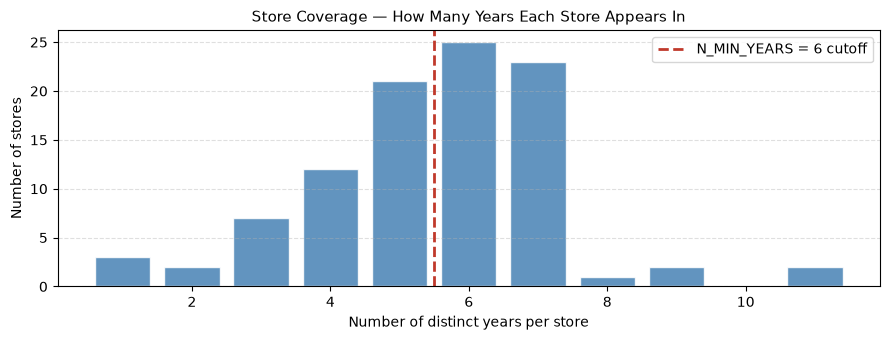

In [141]:
N_MIN_YEARS = 6   # ← adjust as needed

years_per_store = df_occ.groupby("store_id")["year"].nunique()
panel_stores    = years_per_store[years_per_store >= N_MIN_YEARS].index
df_occ_panel    = df_occ[df_occ["store_id"].isin(panel_stores)]

print(f"N_MIN_YEARS = {N_MIN_YEARS}")
print(f"Stores total          : {df_occ['store_id'].nunique()}")
print(f"Stores in panel       : {len(panel_stores)}")
print(f"Stores dropped        : {df_occ['store_id'].nunique() - len(panel_stores)}")
print(f"Images in panel       : {len(df_occ_panel)} / {len(df_occ)}\n")

# Distribution of years-per-store
fig, ax = plt.subplots(figsize=(9, 3.5))
counts = years_per_store.value_counts().sort_index()
ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(N_MIN_YEARS - 0.5, color="#c0392b", linewidth=2, linestyle="--",
           label=f"N_MIN_YEARS = {N_MIN_YEARS} cutoff")
ax.set_xlabel("Number of distinct years per store", fontsize=10)
ax.set_ylabel("Number of stores", fontsize=10)
ax.set_title("Store Coverage — How Many Years Each Store Appears In", fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

  Year    % Δ Revenue    % Δ Occ (panel)   N images
────────────────────────────────────────────────────
  2013         +3.44%            +16.82%         31
  2014         +0.01%             -1.68%         19
  2015         +1.84%             -4.39%         29
  2016         -1.96%            -12.46%         22
  2017         -1.33%            +38.90%         31
  2018         +0.52%            -12.11%         27
  2019         +0.98%            +23.06%         26
  2020         +0.62%            -25.41%         16
  2021         +1.93%            +39.20%         31
  2022         -5.16%             -7.93%         21
  2023         +2.51%            -22.12%         38

Consistent panel (≥6 years)
  Pearson  r  = +0.1342   p = 0.6941  n.s.
  Spearman ρ  = +0.1545   p = 0.6500  n.s.

vs all stores unadjusted (Section 5):  r = -0.3559  ρ = -0.3727


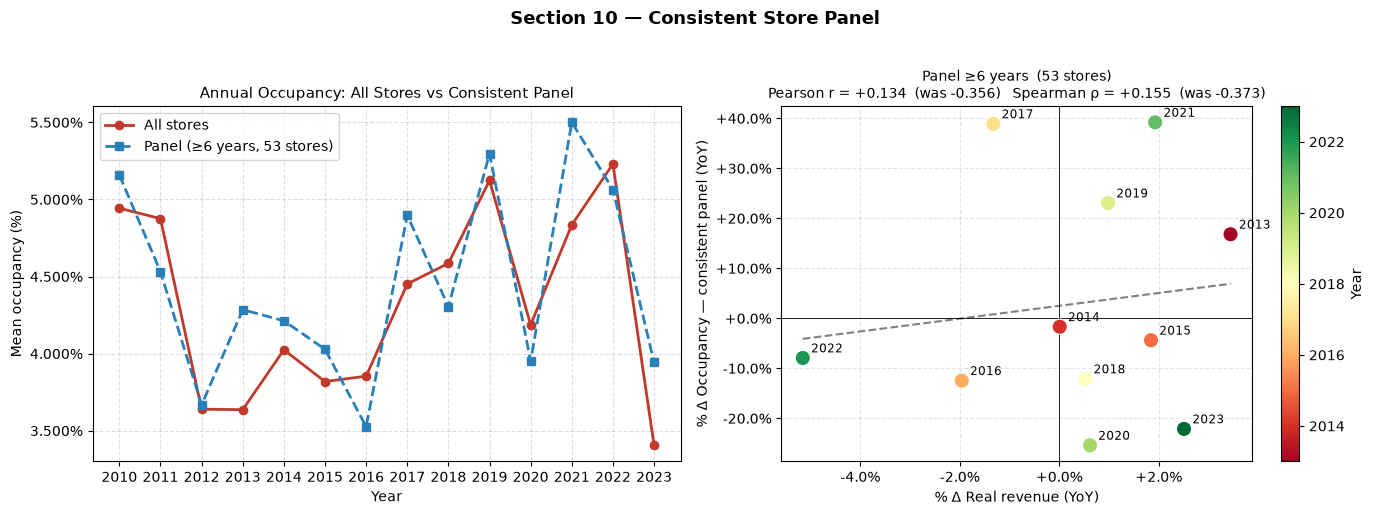

In [142]:
# ── Annual mean over consistent panel ───────────────────────────────────────
occ_annual_panel = (
    df_occ_panel.groupby("year")["occupancy"]
    .agg(occ_mean="mean", occ_std="std", n_images="count")
    .reset_index()
)
occ_annual_panel["occ_pct"] = occ_annual_panel["occ_mean"] * 100

df_merged_panel = pd.merge(df[["year", "revenue_real"]], occ_annual_panel, on="year")

# ── YoY growth rates ─────────────────────────────────────────────────────────
df_diff_panel = df_merged_panel.sort_values("year").reset_index(drop=True)
df_diff_panel["pct_delta_revenue"] = df_diff_panel["revenue_real"].pct_change() * 100
df_diff_panel["pct_delta_occ"]     = df_diff_panel["occ_pct"].pct_change()     * 100
df_diff_panel = df_diff_panel.dropna(subset=["pct_delta_revenue", "pct_delta_occ"])

r_p,   p_p  = stats.pearsonr(df_diff_panel["pct_delta_revenue"], df_diff_panel["pct_delta_occ"])
rho_p, p_sp = stats.spearmanr(df_diff_panel["pct_delta_revenue"], df_diff_panel["pct_delta_occ"])

print(f"{'Year':>6}  {'% Δ Revenue':>13}  {'% Δ Occ (panel)':>17}  {'N images':>9}")
print("─" * 52)
for _, row in df_diff_panel.iterrows():
    n = int(df_merged_panel.loc[df_merged_panel.year == row.year, "n_images"].values[0])
    print(f"{int(row.year):>6}  {row.pct_delta_revenue:>+12.2f}%  {row.pct_delta_occ:>+16.2f}%  {n:>9}")

print(f"\nConsistent panel (≥{N_MIN_YEARS} years)")
print(f"  Pearson  r  = {r_p:+.4f}   p = {p_p:.4f}  {'*** p<0.01' if p_p<0.01 else '** p<0.05' if p_p<0.05 else '* p<0.10' if p_p<0.10 else 'n.s.'}")
print(f"  Spearman ρ  = {rho_p:+.4f}   p = {p_sp:.4f}  {'*** p<0.01' if p_sp<0.01 else '** p<0.05' if p_sp<0.05 else '* p<0.10' if p_sp<0.10 else 'n.s.'}")
print(f"\nvs all stores unadjusted (Section 5):  r = {r_d:+.4f}  ρ = {rho_d:+.4f}")

# ── Summary chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(occ_annual["year"],       occ_annual["occ_pct"],
        marker="o", color="#c0392b",  linewidth=2, label="All stores")
ax.plot(occ_annual_panel["year"], occ_annual_panel["occ_pct"],
        marker="s", color="#2980b9",  linewidth=2, linestyle="--",
        label=f"Panel (≥{N_MIN_YEARS} years, {len(panel_stores)} stores)")
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Mean occupancy (%)", fontsize=10)
ax.set_title("Annual Occupancy: All Stores vs Consistent Panel", fontsize=11)
ax.set_xticks(occ_annual["year"])
ax.legend(fontsize=10)
ax.grid(linestyle="--", alpha=0.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.3f}%"))

ax = axes[1]
sc = ax.scatter(
    df_diff_panel["pct_delta_revenue"],
    df_diff_panel["pct_delta_occ"],
    c=df_diff_panel["year"], cmap="RdYlGn",
    s=120, edgecolors="white", linewidths=0.8, zorder=3
)
for _, row in df_diff_panel.iterrows():
    ax.annotate(str(int(row["year"])),
                (row["pct_delta_revenue"], row["pct_delta_occ"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8.5)
xv = df_diff_panel["pct_delta_revenue"]
m, b = np.polyfit(xv, df_diff_panel["pct_delta_occ"], 1)
xl = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xl, m * xl + b, color="grey", linewidth=1.5, linestyle="--")
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
plt.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("% Δ Real revenue (YoY)", fontsize=10)
ax.set_ylabel("% Δ Occupancy — consistent panel (YoY)", fontsize=10)
ax.set_title(
    f"Panel ≥{N_MIN_YEARS} years  ({len(panel_stores)} stores)\n"
    f"Pearson r = {r_p:+.3f}  (was {r_d:+.3f})   Spearman ρ = {rho_p:+.3f}  (was {rho_d:+.3f})",
    fontsize=10
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.grid(linestyle="--", alpha=0.35)

plt.suptitle("Section 10 — Consistent Store Panel", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---

## 11 · Combined: Consistent Panel + Seasonal Adjustment

Applies both corrections together:

1. **Section 10** filter — keep only stores with ≥ `N_MIN_YEARS` distinct years (removes composition bias)
2. **Section 7** adjustment — divide each image's occupancy by its calendar-month mean, rescale to global mean (removes month-of-year bias)

This is the cleanest occupancy signal available before any model-quality filtering.

In [143]:
# Step 1 — consistent panel filter (reuses panel_stores from Section 10)
df_combined = df_occ[df_occ["store_id"].isin(panel_stores)].copy()

# Step 2 — seasonal adjustment (reuses monthly_mean and global_mean from Section 7)
df_combined = df_combined.merge(monthly_mean, on="month")
df_combined["occ_adj"] = (df_combined["occupancy"] / df_combined["month_mean"]) * global_mean

# Step 3 — annual mean on adjusted panel
occ_annual_combined = (
    df_combined.groupby("year")["occ_adj"]
    .agg(occ_mean="mean", occ_std="std", n_images="count")
    .reset_index()
)
occ_annual_combined["occ_pct"] = occ_annual_combined["occ_mean"] * 100

df_merged_combined = pd.merge(df[["year", "revenue_real"]], occ_annual_combined, on="year")

# Step 4 — YoY growth rates
df_diff_combined = df_merged_combined.sort_values("year").reset_index(drop=True)
df_diff_combined["pct_delta_revenue"] = df_diff_combined["revenue_real"].pct_change() * 100
df_diff_combined["pct_delta_occ"]     = df_diff_combined["occ_pct"].pct_change()     * 100
df_diff_combined = df_diff_combined.dropna(subset=["pct_delta_revenue", "pct_delta_occ"])

r_cb,   p_cb  = stats.pearsonr(df_diff_combined["pct_delta_revenue"], df_diff_combined["pct_delta_occ"])
rho_cb, p_scb = stats.spearmanr(df_diff_combined["pct_delta_revenue"], df_diff_combined["pct_delta_occ"])

print(f"Panel stores   : {len(panel_stores)}  (≥{N_MIN_YEARS} years)")
print(f"Images used    : {len(df_combined)} / {len(df_occ)}\n")
print(f"{'Year':>6}  {'% Δ Revenue':>13}  {'% Δ Occ (combined)':>20}")
print("─" * 46)
for _, row in df_diff_combined.iterrows():
    print(f"{int(row.year):>6}  {row.pct_delta_revenue:>+12.2f}%  {row.pct_delta_occ:>+19.2f}%")

print(f"\nCombined (panel + seasonal adj)")
print(f"  Pearson  r  = {r_cb:+.4f}   p = {p_cb:.4f}  {'*** p<0.01' if p_cb<0.01 else '** p<0.05' if p_cb<0.05 else '* p<0.10' if p_cb<0.10 else 'n.s.'}")
print(f"  Spearman ρ  = {rho_cb:+.4f}   p = {p_scb:.4f}  {'*** p<0.01' if p_scb<0.01 else '** p<0.05' if p_scb<0.05 else '* p<0.10' if p_scb<0.10 else 'n.s.'}")

Panel stores   : 53  (≥6 years)
Images used    : 372 / 559

  Year    % Δ Revenue    % Δ Occ (combined)
──────────────────────────────────────────────
  2013         +3.44%               +25.01%
  2014         +0.01%                -2.79%
  2015         +1.84%                -8.43%
  2016         -1.96%                -8.61%
  2017         -1.33%               +38.00%
  2018         +0.52%               -16.33%
  2019         +0.98%               +27.80%
  2020         +0.62%               -26.78%
  2021         +1.93%               +33.11%
  2022         -5.16%                -4.99%
  2023         +2.51%               -22.12%

Combined (panel + seasonal adj)
  Pearson  r  = +0.1114   p = 0.7443  n.s.
  Spearman ρ  = +0.0091   p = 0.9788  n.s.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Left: all four annual occupancy series ───────────────────────────────────
ax = axes[0]
series = [
    (occ_annual,          "Raw — all stores",              "#c0392b", "o",  "-"),
    (occ_annual_adj,      "Seasonal adj — all stores",     "#e67e22", "o",  "--"),
    (occ_annual_panel,    f"Panel ≥{N_MIN_YEARS}y — raw",  "#2980b9", "s",  "-"),
    (occ_annual_combined, f"Panel ≥{N_MIN_YEARS}y + adj",  "#27ae60", "s",  "--"),
]
for tbl, label, color, marker, ls in series:
    ax.plot(tbl["year"], tbl["occ_pct"],
            color=color, marker=marker, linewidth=2, linestyle=ls, label=label)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Mean occupancy (%)", fontsize=10)
ax.set_title("Annual Occupancy — All Variants", fontsize=11)
ax.set_xticks(occ_annual["year"])
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.3f}%"))
ax.legend(fontsize=8)
ax.grid(linestyle="--", alpha=0.4)

# ── Centre: YoY growth rates as dual-axis line graph ────────────────────────
ax1 = axes[1]
ax2 = ax1.twinx()

color_rev = "#2980b9"
color_occ = "#27ae60"

ax1.plot(df_diff_combined["year"], df_diff_combined["pct_delta_revenue"],
         color=color_rev, marker="o", linewidth=2.5, markersize=8, label="% Δ Real revenue (left)")
ax1.fill_between(df_diff_combined["year"], df_diff_combined["pct_delta_revenue"],
                 alpha=0.08, color=color_rev)
ax1.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)

ax2.plot(df_diff_combined["year"], df_diff_combined["pct_delta_occ"],
         color=color_occ, marker="s", linewidth=2.5, markersize=8,
         linestyle="--", label="% Δ Occupancy (right)")
ax2.fill_between(df_diff_combined["year"], df_diff_combined["pct_delta_occ"],
                 alpha=0.08, color=color_occ)

ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("% Δ Real revenue (YoY)", fontsize=10, color=color_rev)
ax1.tick_params(axis="y", labelcolor=color_rev)
ax1.tick_params(axis="x", rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax2.set_ylabel("% Δ Occupancy (YoY)", fontsize=10, color=color_occ)
ax2.tick_params(axis="y", labelcolor=color_occ)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax1.set_xticks(df_diff_combined["year"])

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, fontsize=9, loc="upper left")
ax1.set_title(
    f"YoY Growth Rates Over Time\n(panel ≥{N_MIN_YEARS}y + seasonal adj)",
    fontsize=11
)
ax1.grid(axis="x", linestyle="--", alpha=0.3)

# ── Right: scatter ───────────────────────────────────────────────────────────
ax = axes[2]
sc = ax.scatter(
    df_diff_combined["pct_delta_revenue"],
    df_diff_combined["pct_delta_occ"],
    c=df_diff_combined["year"], cmap="RdYlGn",
    s=130, edgecolors="white", linewidths=0.8, zorder=3
)
for _, row in df_diff_combined.iterrows():
    ax.annotate(str(int(row["year"])),
                (row["pct_delta_revenue"], row["pct_delta_occ"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8.5)
xv = df_diff_combined["pct_delta_revenue"]
m, b = np.polyfit(xv, df_diff_combined["pct_delta_occ"], 1)
xl = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xl, m * xl + b, color="grey", linewidth=1.5, linestyle="--")
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
plt.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("% Δ Real revenue (YoY)", fontsize=10)
ax.set_ylabel("% Δ Occupancy — panel + seasonal adj (YoY)", fontsize=10)
ax.set_title(
    f"Scatter  (panel ≥{N_MIN_YEARS}y + seasonal adj)\n"
    f"Pearson r = {r_cb:+.3f}   Spearman ρ = {rho_cb:+.3f}",
    fontsize=11
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.grid(linestyle="--", alpha=0.35)

plt.suptitle("Section 11 — Combined: Consistent Panel + Seasonal Adjustment",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table of all approaches ─────────────────────────────────────────
print("\n── Summary across all approaches ──────────────────────────────────────")
print(f"{'Section':<40}  {'Pearson r':>10}  {'Spearman ρ':>11}")
print("─" * 66)
for label, r_val, rho_val in [
    ("§2  Levels (baseline)",                  r,     rho),
    ("§5  YoY growth rates",                   r_d,   rho_d),
    ("§6  YoY + outlier filter (P10/P90)",     r_c,   rho_c),
    ("§7  YoY + seasonal adj",                 r_adj, rho_adj),
    ("§10 YoY + consistent panel",             r_p,   rho_p),
    (f"§11 YoY + panel + seasonal adj  ★",     r_cb,  rho_cb),
]:
    print(f"{label:<40}  {r_val:>+10.4f}  {rho_val:>+11.4f}")

---

## 12 · Within-Store Seasonal Index

Section 7's index is built from raw monthly means across all stores. The problem: a store that is always busy inflates the index for whichever months it happens to be imaged in, mixing store-level differences with the seasonal pattern.

**Fix:** compute each image's deviation from its **own store's mean**, then average those deviations by calendar month. The index now captures only the within-store seasonal swing — how much a store's occupancy typically differs in a given month from its own baseline, stripped of cross-store level differences.

`dev_i = occ_i − store_mean(store_id_i)`  
`monthly_dev[m] = mean(dev_i  for all images in month m)`  
`occ_adj_i = occ_i − monthly_dev[month_i]`  (additive correction)

In [ ]:
# ── Within-store seasonal index ─────────────────────────────────────────────
store_mean_occ = df_occ.groupby("store_id")["occupancy"].mean().rename("store_mean")

df_ws = df_occ.join(store_mean_occ, on="store_id")
df_ws["dev_from_store"] = df_ws["occupancy"] - df_ws["store_mean"]

# Monthly index = mean within-store deviation for each calendar month
monthly_dev = df_ws.groupby("month")["dev_from_store"].mean().rename("monthly_dev")

df_ws = df_ws.join(monthly_dev, on="month")
df_ws["occ_adj_ws"] = df_ws["occupancy"] - df_ws["monthly_dev"]

# Print index: compare §7 (cross-store) vs §12 (within-store)
print(f"{'Month':>6}  {'§7 raw mean':>12}  {'§12 within-store dev':>21}  {'N images':>9}")
print("─" * 56)
for m in range(1, 13):
    raw_m  = df_occ[df_occ["month"] == m]["occupancy"].mean()
    dev_m  = monthly_dev.get(m, float("nan"))
    n_m    = int((df_occ["month"] == m).sum())
    print(f"{m:>6}  {raw_m*100:>11.4f}%  {dev_m*100:>+20.4f}pp  {n_m:>9}")

In [ ]:
# ── Apply to consistent panel + compute annual mean ─────────────────────────
df_ws_panel = df_ws[df_ws["store_id"].isin(panel_stores)].copy()

occ_annual_ws = (
    df_ws_panel.groupby("year")["occ_adj_ws"]
    .agg(occ_mean="mean", occ_std="std", n_images="count")
    .reset_index()
)
occ_annual_ws["occ_pct"] = occ_annual_ws["occ_mean"] * 100

df_merged_ws = pd.merge(df[["year", "revenue_real"]], occ_annual_ws, on="year")

# ── YoY growth rates ─────────────────────────────────────────────────────────
df_diff_ws = df_merged_ws.sort_values("year").reset_index(drop=True)
df_diff_ws["pct_delta_revenue"] = df_diff_ws["revenue_real"].pct_change() * 100
df_diff_ws["pct_delta_occ"]     = df_diff_ws["occ_pct"].pct_change()     * 100
df_diff_ws = df_diff_ws.dropna(subset=["pct_delta_revenue", "pct_delta_occ"])

r_ws,   p_ws  = stats.pearsonr(df_diff_ws["pct_delta_revenue"], df_diff_ws["pct_delta_occ"])
rho_ws, p_sws = stats.spearmanr(df_diff_ws["pct_delta_revenue"], df_diff_ws["pct_delta_occ"])

print(f"{'Year':>6}  {'% Δ Revenue':>13}  {'% Δ Occ (within-store adj)':>28}")
print("─" * 52)
for _, row in df_diff_ws.iterrows():
    print(f"{int(row.year):>6}  {row.pct_delta_revenue:>+12.2f}%  {row.pct_delta_occ:>+27.2f}%")

print(f"\nWithin-store seasonal adj + panel ≥{N_MIN_YEARS}y")
print(f"  Pearson  r  = {r_ws:+.4f}   p = {p_ws:.4f}  {'*** p<0.01' if p_ws<0.01 else '** p<0.05' if p_ws<0.05 else '* p<0.10' if p_ws<0.10 else 'n.s.'}")
print(f"  Spearman ρ  = {rho_ws:+.4f}   p = {p_sws:.4f}  {'*** p<0.01' if p_sws<0.01 else '** p<0.05' if p_sws<0.05 else '* p<0.10' if p_sws<0.10 else 'n.s.'}")
print(f"\nvs §11 (cross-store adj + panel):  r = {r_cb:+.4f}  ρ = {rho_cb:+.4f}")
print(f"vs §7  (cross-store adj only):     r = {r_adj:+.4f}  ρ = {rho_adj:+.4f}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Left: seasonal index comparison §7 vs §12 ───────────────────────────────
ax = axes[0]
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
all_months = pd.Index(range(1, 13), name="month")
x = np.arange(1, 13)

# reindex to all 12 months so shapes always match
sec7_dev    = (df_occ.groupby("month")["occupancy"].mean() - global_mean).reindex(all_months, fill_value=0)
monthly_dev_plot = monthly_dev.reindex(all_months, fill_value=0)

ax.bar(x - 0.2, sec7_dev * 100,         width=0.38, color="#e67e22", alpha=0.8, label="§7 cross-store index")
ax.bar(x + 0.2, monthly_dev_plot * 100, width=0.38, color="#27ae60", alpha=0.8, label="§12 within-store index")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(month_names, fontsize=9)
ax.set_ylabel("Seasonal deviation (pp)", fontsize=10)
ax.set_title("Seasonal Index: §7 Cross-Store vs §12 Within-Store", fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.3f}pp"))
ax.legend(fontsize=9)
ax.grid(axis="y", linestyle="--", alpha=0.4)

# ── Centre: dual-axis line graph YoY growth rates ────────────────────────────
ax1 = axes[1]
ax2 = ax1.twinx()

color_rev = "#2980b9"
color_occ = "#27ae60"

ax1.plot(df_diff_ws["year"], df_diff_ws["pct_delta_revenue"],
         color=color_rev, marker="o", linewidth=2.5, markersize=8,
         label="% Δ Real revenue (left)")
ax1.fill_between(df_diff_ws["year"], df_diff_ws["pct_delta_revenue"],
                 alpha=0.08, color=color_rev)
ax1.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)

ax2.plot(df_diff_ws["year"], df_diff_ws["pct_delta_occ"],
         color=color_occ, marker="s", linewidth=2.5, markersize=8,
         linestyle="--", label="% Δ Occupancy within-store adj (right)")
ax2.fill_between(df_diff_ws["year"], df_diff_ws["pct_delta_occ"],
                 alpha=0.08, color=color_occ)

ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("% Δ Real revenue (YoY)", fontsize=10, color=color_rev)
ax1.tick_params(axis="y", labelcolor=color_rev)
ax1.tick_params(axis="x", rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax2.set_ylabel("% Δ Occupancy (YoY)", fontsize=10, color=color_occ)
ax2.tick_params(axis="y", labelcolor=color_occ)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax1.set_xticks(df_diff_ws["year"])
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, fontsize=8.5, loc="upper left")
ax1.set_title(
    f"YoY Growth Rates Over Time\n(panel ≥{N_MIN_YEARS}y + within-store seasonal adj)",
    fontsize=11
)
ax1.grid(axis="x", linestyle="--", alpha=0.3)

# ── Right: scatter ───────────────────────────────────────────────────────────
ax = axes[2]
sc = ax.scatter(
    df_diff_ws["pct_delta_revenue"],
    df_diff_ws["pct_delta_occ"],
    c=df_diff_ws["year"], cmap="RdYlGn",
    s=130, edgecolors="white", linewidths=0.8, zorder=3
)
for _, row in df_diff_ws.iterrows():
    ax.annotate(str(int(row["year"])),
                (row["pct_delta_revenue"], row["pct_delta_occ"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8.5)
xv = df_diff_ws["pct_delta_revenue"]
m_fit, b_fit = np.polyfit(xv, df_diff_ws["pct_delta_occ"], 1)
xl = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xl, m_fit * xl + b_fit, color="grey", linewidth=1.5, linestyle="--")
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
plt.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("% Δ Real revenue (YoY)", fontsize=10)
ax.set_ylabel("% Δ Occupancy — within-store adj (YoY)", fontsize=10)
ax.set_title(
    f"Scatter  (panel ≥{N_MIN_YEARS}y + within-store adj)\n"
    f"Pearson r = {r_ws:+.3f}   Spearman ρ = {rho_ws:+.3f}",
    fontsize=11
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.grid(linestyle="--", alpha=0.35)

plt.suptitle("Section 12 — Within-Store Seasonal Index (+ Consistent Panel)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Updated full summary ─────────────────────────────────────────────────────
print("\n── Summary across all approaches ──────────────────────────────────────")
print(f"{'Section':<45}  {'Pearson r':>10}  {'Spearman ρ':>11}")
print("─" * 71)
for label, r_val, rho_val in [
    ("§2  Levels (baseline)",                    r,     rho),
    ("§5  YoY growth rates",                     r_d,   rho_d),
    ("§6  YoY + outlier filter (P10/P90)",       r_c,   rho_c),
    ("§7  YoY + cross-store seasonal adj",       r_adj, rho_adj),
    ("§10 YoY + consistent panel",               r_p,   rho_p),
    ("§11 YoY + panel + cross-store adj",        r_cb,  rho_cb),
    ("§12 YoY + panel + within-store adj  ★",    r_ws,  rho_ws),
]:
    print(f"{label:<45}  {r_val:>+10.4f}  {rho_val:>+11.4f}")

---

## 13 · Within-Store YoY + Consistent Panel (No Seasonal Adjustment)

Instead of adjusting for seasonality and then averaging across stores, compute the **YoY change within each store first**, then average those store-level rates per year.

This naturally absorbs store-level baseline differences and the composition bias (different stores imaged each year), without any seasonal index assumption.

`annual_mean[store, year] = mean(occupancy for all images of that store in that year)`  
`yoy[store, year] = pct_change(annual_mean[store]) * 100`  
`agg_yoy[year] = mean(yoy[store, year]  across all panel stores observed in year t and t-1)`

In [ ]:
# ── Annual mean per store (panel only, no SA) ────────────────────────────────
df_panel_raw = df_occ[df_occ["store_id"].isin(panel_stores)].copy()

store_annual = (
    df_panel_raw.groupby(["store_id", "year"])["occupancy"]
    .mean()
    .reset_index()
    .sort_values(["store_id", "year"])
)

# YoY % change within each store
store_annual["yoy_store"] = (
    store_annual.groupby("store_id")["occupancy"]
    .pct_change() * 100
)
store_annual = store_annual.dropna(subset=["yoy_store"])

# Average store-level YoY per calendar year
agg_yoy = (
    store_annual.groupby("year")["yoy_store"]
    .agg(pct_delta_occ="mean", n_stores="count")
    .reset_index()
)

# Revenue YoY
rev_yoy = df[["year", "revenue_real"]].sort_values("year").copy()
rev_yoy["pct_delta_revenue"] = rev_yoy["revenue_real"].pct_change() * 100
rev_yoy = rev_yoy.dropna(subset=["pct_delta_revenue"])

df_s13 = pd.merge(rev_yoy[["year", "pct_delta_revenue"]], agg_yoy, on="year")

r_s13,   p_s13  = stats.pearsonr(df_s13["pct_delta_revenue"], df_s13["pct_delta_occ"])
rho_s13, p_srs13 = stats.spearmanr(df_s13["pct_delta_revenue"], df_s13["pct_delta_occ"])

print(f"{'Year':>6}  {'% Δ Revenue':>13}  {'Avg store-level % Δ Occ':>25}  {'N stores':>9}")
print("─" * 60)
for _, row in df_s13.iterrows():
    print(f"{int(row.year):>6}  {row.pct_delta_revenue:>+12.2f}%  {row.pct_delta_occ:>+24.2f}%  {int(row.n_stores):>9}")

print(f"\nWithin-store YoY + panel ≥{N_MIN_YEARS}y  (no seasonal adj)")
print(f"  Pearson  r  = {r_s13:+.4f}   p = {p_s13:.4f}  {'*** p<0.01' if p_s13<0.01 else '** p<0.05' if p_s13<0.05 else '* p<0.10' if p_s13<0.10 else 'n.s.'}")
print(f"  Spearman ρ  = {rho_s13:+.4f}   p = {p_srs13:.4f}  {'*** p<0.01' if p_srs13<0.01 else '** p<0.05' if p_srs13<0.05 else '* p<0.10' if p_srs13<0.10 else 'n.s.'}")
print(f"\nvs §12 (panel + within-store SA):  r = {r_ws:+.4f}  ρ = {rho_ws:+.4f}")
print(f"vs §11 (panel + cross-store SA):   r = {r_cb:+.4f}  ρ = {rho_cb:+.4f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: dual-axis line graph ───────────────────────────────────────────────
ax1 = axes[0]
ax2 = ax1.twinx()

color_rev = "#2980b9"
color_occ = "#8e44ad"

ax1.plot(df_s13["year"], df_s13["pct_delta_revenue"],
         color=color_rev, marker="o", linewidth=2.5, markersize=8,
         label="% Δ Real revenue (left)")
ax1.fill_between(df_s13["year"], df_s13["pct_delta_revenue"],
                 alpha=0.08, color=color_rev)
ax1.axhline(0, color="black", linewidth=0.7, linestyle="--", alpha=0.5)

ax2.plot(df_s13["year"], df_s13["pct_delta_occ"],
         color=color_occ, marker="s", linewidth=2.5, markersize=8,
         linestyle="--", label="Avg store-level % Δ Occ (right)")
ax2.fill_between(df_s13["year"], df_s13["pct_delta_occ"],
                 alpha=0.08, color=color_occ)

ax1.set_xlabel("Year", fontsize=10)
ax1.set_ylabel("% Δ Real revenue (YoY)", fontsize=10, color=color_rev)
ax1.tick_params(axis="y", labelcolor=color_rev)
ax1.tick_params(axis="x", rotation=45)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax2.set_ylabel("Avg store-level % Δ Occ (YoY)", fontsize=10, color=color_occ)
ax2.tick_params(axis="y", labelcolor=color_occ)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax1.set_xticks(df_s13["year"])
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, fontsize=8.5, loc="upper left")
ax1.set_title(
    f"YoY Growth Rates — Within-Store (panel ≥{N_MIN_YEARS}y, no SA)",
    fontsize=11
)
ax1.grid(axis="x", linestyle="--", alpha=0.3)

# ── Right: scatter ───────────────────────────────────────────────────────────
ax = axes[1]
sc = ax.scatter(
    df_s13["pct_delta_revenue"], df_s13["pct_delta_occ"],
    c=df_s13["year"], cmap="RdYlGn",
    s=130, edgecolors="white", linewidths=0.8, zorder=3
)
for _, row in df_s13.iterrows():
    ax.annotate(str(int(row["year"])),
                (row["pct_delta_revenue"], row["pct_delta_occ"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8.5)
xv = df_s13["pct_delta_revenue"]
m_fit, b_fit = np.polyfit(xv, df_s13["pct_delta_occ"], 1)
xl = np.linspace(xv.min(), xv.max(), 100)
ax.plot(xl, m_fit * xl + b_fit, color="grey", linewidth=1.5, linestyle="--")
ax.axhline(0, color="black", linewidth=0.6)
ax.axvline(0, color="black", linewidth=0.6)
plt.colorbar(sc, ax=ax, label="Year")
ax.set_xlabel("% Δ Real revenue (YoY)", fontsize=10)
ax.set_ylabel("Avg store-level % Δ Occupancy (YoY)", fontsize=10)
ax.set_title(
    f"Scatter  (panel ≥{N_MIN_YEARS}y, within-store YoY, no SA)\n"
    f"Pearson r = {r_s13:+.3f}   Spearman ρ = {rho_s13:+.3f}",
    fontsize=11
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:+.1f}%"))
ax.grid(linestyle="--", alpha=0.35)

plt.suptitle("Section 13 — Within-Store YoY + Consistent Panel (No Seasonal Adjustment)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ── Full summary table ───────────────────────────────────────────────────────
print("\n── Summary across all approaches ──────────────────────────────────────")
print(f"{'Section':<48}  {'Pearson r':>10}  {'Spearman ρ':>11}")
print("─" * 74)
for label, r_val, rho_val in [
    ("§2  Levels (baseline)",                       r,      rho),
    ("§5  YoY growth rates",                        r_d,    rho_d),
    ("§6  YoY + outlier filter (P10/P90)",          r_c,    rho_c),
    ("§7  YoY + cross-store seasonal adj",          r_adj,  rho_adj),
    ("§10 YoY + consistent panel",                  r_p,    rho_p),
    ("§11 YoY + panel + cross-store SA",            r_cb,   rho_cb),
    ("§12 YoY + panel + within-store SA",           r_ws,   rho_ws),
    ("§13 Within-store YoY + panel (no SA)  ★",    r_s13,  rho_s13),
]:
    print(f"{label:<48}  {r_val:>+10.4f}  {rho_val:>+11.4f}")